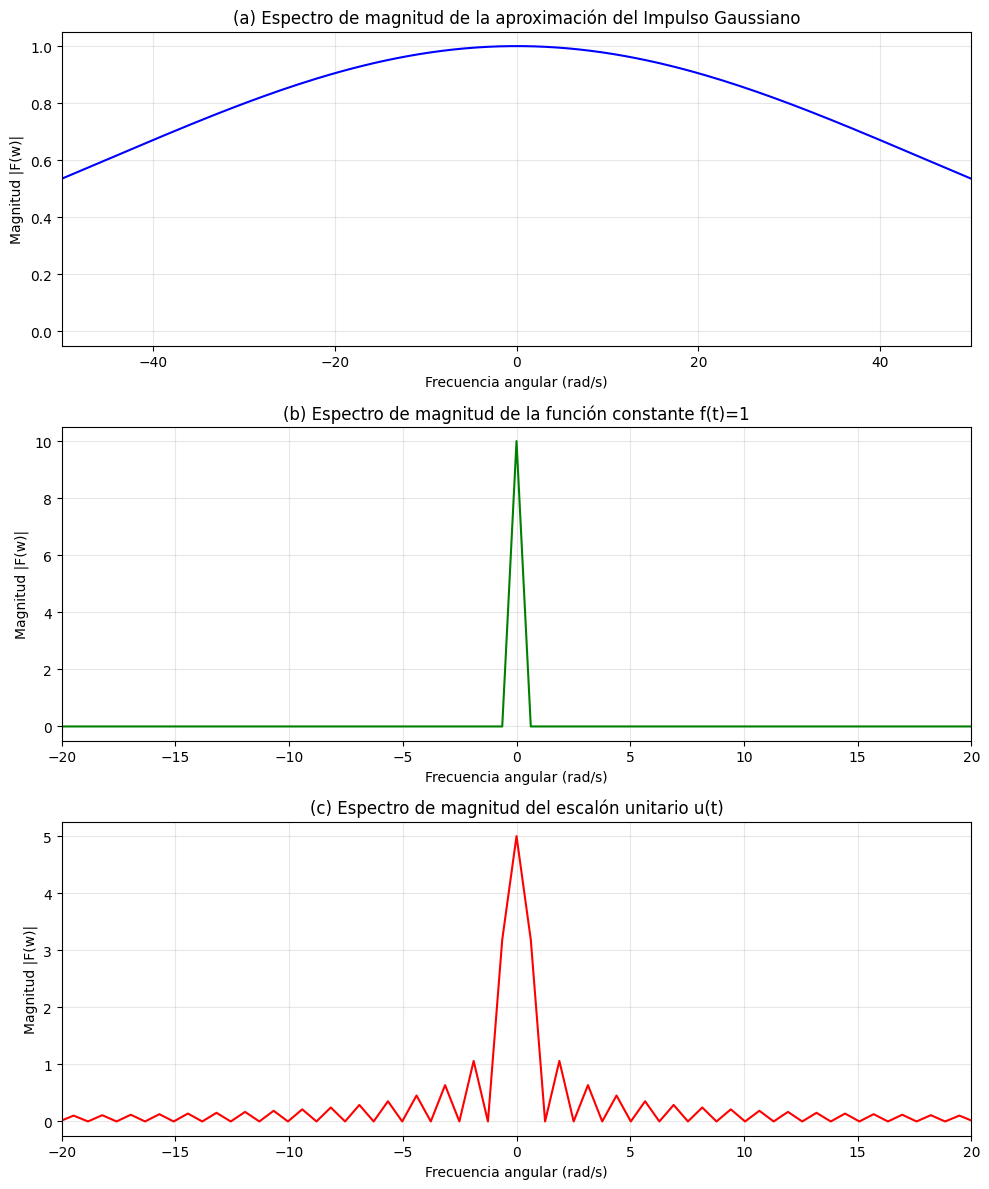

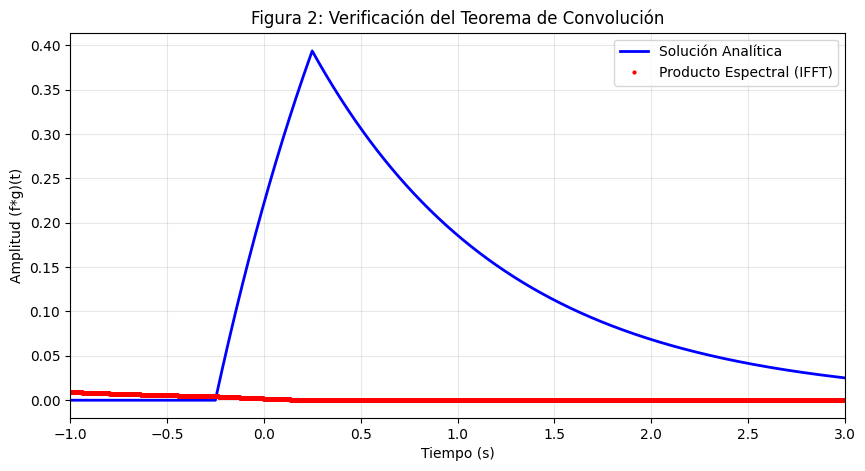

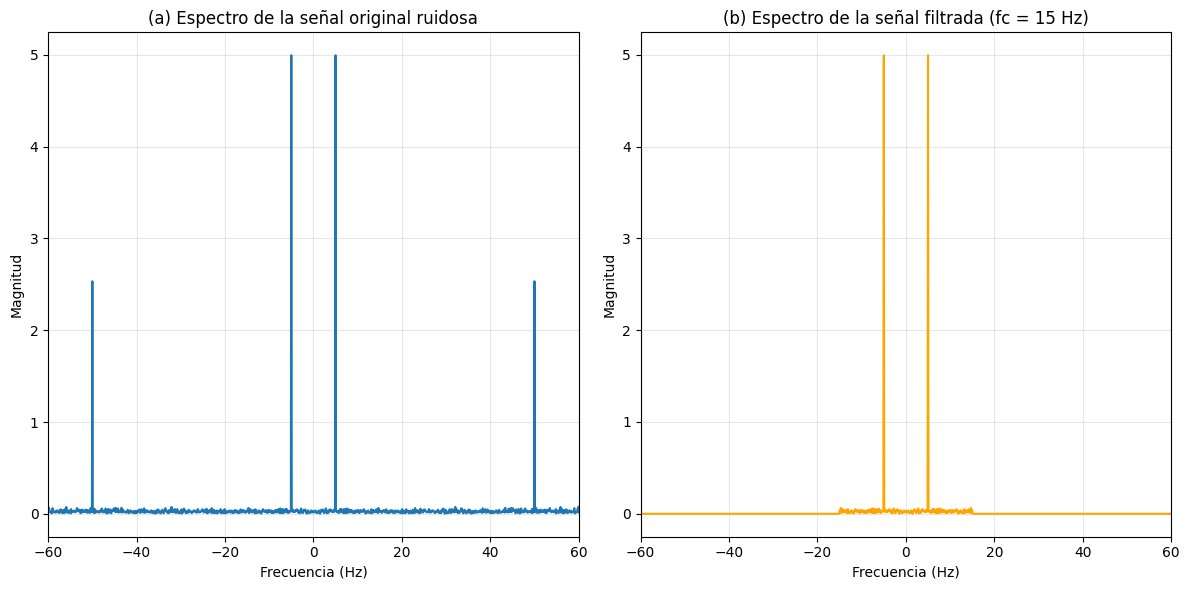

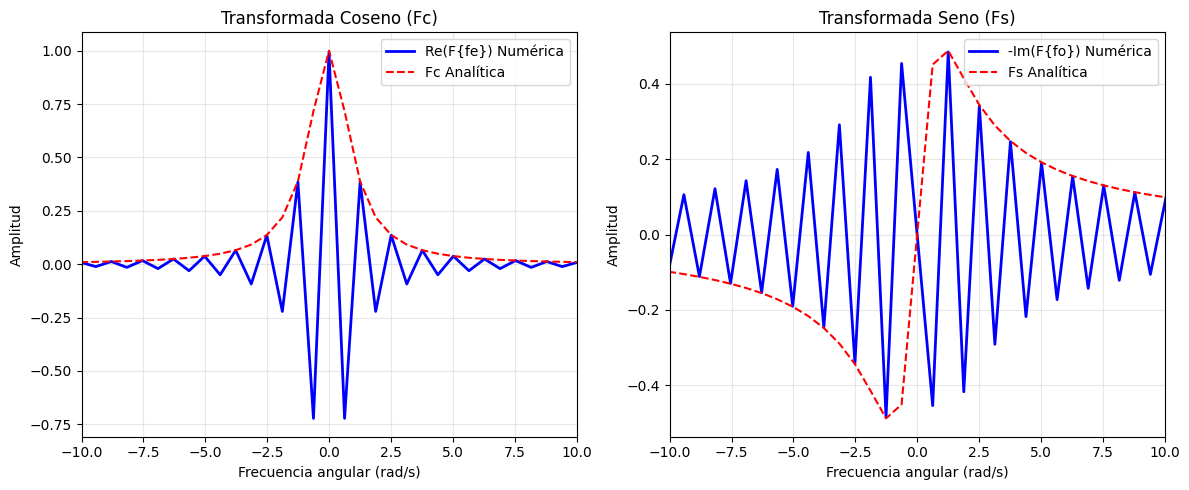

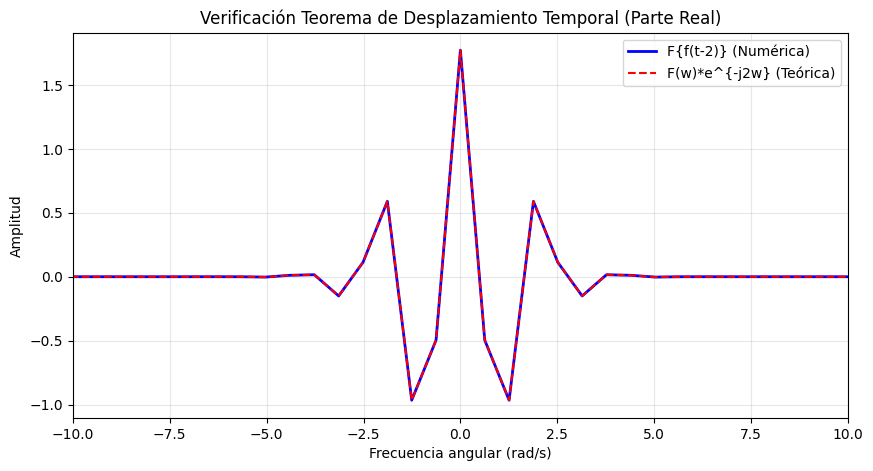

VERIFICACIÓN DEL TEOREMA DE PARSEVAL
Energía en el dominio del tiempo (Et): 1.253314
Energía en el dominio de la frecuencia (Ef): 1.253314
Error absoluto: 2.220446e-16


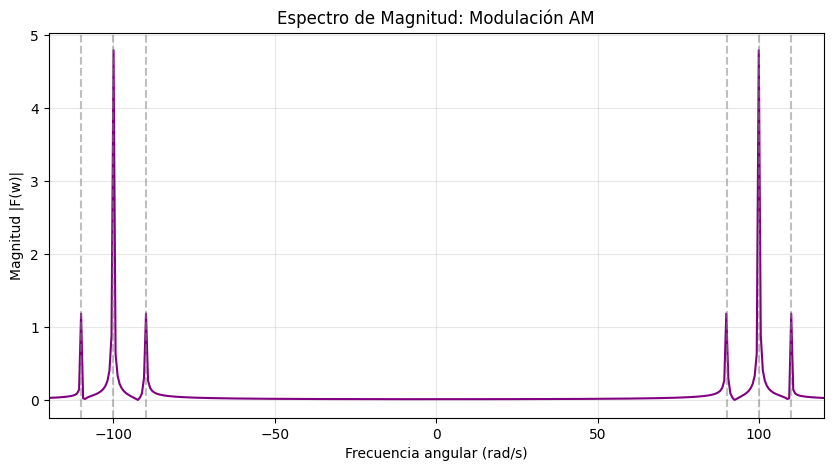

In [2]:
import numpy as np
from scipy.fft import fft, fftfreq, fftshift, ifft
import matplotlib.pyplot as plt

# ==========================================
# PARÁMETROS GENERALES
# ==========================================
Fs = 1000   # Frecuencia de muestreo (Hz)
T = 10      # Duración de la ventana (s)
N = int(Fs * T) # Número de muestras
t = np.linspace(-T/2, T/2, N, endpoint=False)
dt = t[1] - t[0]
w = 2 * np.pi * fftfreq(N, dt)
w_shifted = fftshift(w)

# ==========================================
# ACTIVIDAD 1: SEÑALES CANÓNICAS (Figura 1)
# ==========================================
# 1. Impulso (Gaussiana)
eps = 0.001
f_eps = np.exp(-(t**2) / eps) / np.sqrt(np.pi * eps)
F_eps = fftshift(fft(f_eps) * dt)

# 2. Constante f(t) = 1
f_const = np.ones_like(t)
F_const = fftshift(fft(f_const) * dt)

# 3. Escalón unitario u(t)
u = (t >= 0).astype(float)
U = fftshift(fft(u) * dt)

plt.figure(figsize=(10, 12))
# Subplot A: Impulso
plt.subplot(3, 1, 1)
plt.plot(w_shifted, np.abs(F_eps), color='blue')
plt.xlim(-50, 50)
plt.title('(a) Espectro de magnitud de la aproximación del Impulso Gaussiano')
plt.xlabel('Frecuencia angular (rad/s)')
plt.ylabel('Magnitud |F(w)|')
plt.grid(True, alpha=0.3)

# Subplot B: Constante
plt.subplot(3, 1, 2)
plt.plot(w_shifted, np.abs(F_const), color='green')
plt.xlim(-20, 20)
plt.title('(b) Espectro de magnitud de la función constante f(t)=1')
plt.xlabel('Frecuencia angular (rad/s)')
plt.ylabel('Magnitud |F(w)|')
plt.grid(True, alpha=0.3)

# Subplot C: Escalón
plt.subplot(3, 1, 3)
plt.plot(w_shifted, np.abs(U), color='red')
plt.xlim(-20, 20)
plt.title('(c) Espectro de magnitud del escalón unitario u(t)')
plt.xlabel('Frecuencia angular (rad/s)')
plt.ylabel('Magnitud |F(w)|')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# ACTIVIDAD 2: CONVOLUCIÓN (Figura 2)
# ==========================================
tau = 0.5
f_rect = np.where(np.abs(t) <= tau/2, 1.0, 0.0)
g_exp = np.exp(-t) * (t >= 0)

# 1. Convolución mediante espectros (FFT)
F_rect = fft(f_rect) * dt
G_exp = fft(g_exp) * dt
conv_fft = np.real(ifft(F_rect * G_exp / dt))

# 2. Convolución Analítica (Por tramos)
conv_ana = np.zeros_like(t)
for i, time in enumerate(t):
    if -tau/2 <= time <= tau/2:
        conv_ana[i] = 1 - np.exp(-(time + tau/2))
    elif time > tau/2:
        conv_ana[i] = 2 * np.sinh(tau/2) * np.exp(-time)

plt.figure(figsize=(10, 5))
plt.plot(t, conv_ana, 'b-', linewidth=2, label='Solución Analítica')
plt.plot(t, conv_fft, 'r.', markersize=4, label='Producto Espectral (IFFT)')
plt.xlim(-1, 3)
plt.title('Figura 2: Verificación del Teorema de Convolución')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (f*g)(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# ACTIVIDAD 2.4: FILTRO PASO-BAJO (Figura 3)
# ==========================================
# Señal compuesta: 5Hz + 50Hz + Ruido
f_signal = np.cos(2 * np.pi * 5 * t) + 0.5 * np.cos(2 * np.pi * 50 * t) + np.random.normal(0, 0.3, N)
F_signal = fft(f_signal) * dt
frecuencias = fftfreq(N, dt)

# Filtro ideal (Corte en 15 Hz)
H = np.where(np.abs(frecuencias) <= 15, 1.0, 0.0)
F_filtrada = F_signal * H
f_filtrada = np.real(ifft(F_filtrada / dt))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(fftshift(frecuencias), np.abs(fftshift(F_signal)))
plt.xlim(-60, 60)
plt.title('(a) Espectro de la señal original ruidosa')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(fftshift(frecuencias), np.abs(fftshift(F_filtrada)), color='orange')
plt.xlim(-60, 60)
plt.title('(b) Espectro de la señal filtrada (fc = 15 Hz)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# ACTIVIDAD 3: TRANSFORMADAS SENO Y COSENO
# ==========================================
a = 1.0
# Extensiones par e impar para f(t) = e^(-at)u(t)
f_e = np.exp(-a * np.abs(t)) / 2.0
f_o = np.sign(t) * np.exp(-a * np.abs(t)) / 2.0

# Transformadas numéricas mediante FFT
F_fe = fftshift(fft(f_e) * dt)
F_fo = fftshift(fft(f_o) * dt)

# Fórmulas analíticas teóricas
Fc_ana = a / (a**2 + w_shifted**2)
Fs_ana = w_shifted / (a**2 + w_shifted**2)

plt.figure(figsize=(12, 5))

# Gráfica Coseno
plt.subplot(1, 2, 1)
plt.plot(w_shifted, np.real(F_fe), 'b-', linewidth=2, label='Re(F{fe}) Numérica')
plt.plot(w_shifted, Fc_ana, 'r--', label='Fc Analítica')
plt.xlim(-10, 10)
plt.title('Transformada Coseno (Fc)')
plt.xlabel('Frecuencia angular (rad/s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica Seno
plt.subplot(1, 2, 2)
# Nota: La convención matemática indica que Im(F{fo}) se relaciona con Fs
plt.plot(w_shifted, -np.imag(F_fo), 'b-', linewidth=2, label='-Im(F{fo}) Numérica')
plt.plot(w_shifted, Fs_ana, 'r--', label='Fs Analítica')
plt.xlim(-10, 10)
plt.title('Transformada Seno (Fs)')
plt.xlabel('Frecuencia angular (rad/s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# ACTIVIDAD 4.1: DESPLAZAMIENTO TEMPORAL
# ==========================================
t0 = 2.0
f_base = np.exp(-(t**2))
f_desplazada = np.exp(-((t - t0)**2))

F_base = fftshift(fft(f_base) * dt)
F_desplazada_num = fftshift(fft(f_desplazada) * dt)

# Aplicación del teorema: F{f(t-t0)} = F(w) * e^(-jw*t0)
F_desplazada_teo = F_base * np.exp(-1j * w_shifted * t0)

plt.figure(figsize=(10, 5))
plt.plot(w_shifted, np.real(F_desplazada_num), 'b-', linewidth=2, label='F{f(t-2)} (Numérica)')
plt.plot(w_shifted, np.real(F_desplazada_teo), 'r--', label='F(w)*e^{-j2w} (Teórica)')
plt.xlim(-10, 10)
plt.title('Verificación Teorema de Desplazamiento Temporal (Parte Real)')
plt.xlabel('Frecuencia angular (rad/s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# ACTIVIDAD 4.2: TEOREMA DE PARSEVAL
# ==========================================
f_pars = np.exp(-(t**2))
F_pars = fft(f_pars) * dt
dw = w[1] - w[0]

# Cálculo de energías
energia_tiempo = np.sum(np.abs(f_pars)**2) * dt
energia_frecuencia = (1 / (2 * np.pi)) * np.sum(np.abs(F_pars)**2) * dw

print("==========================================")
print("VERIFICACIÓN DEL TEOREMA DE PARSEVAL")
print("==========================================")
print(f"Energía en el dominio del tiempo (Et): {energia_tiempo:.6f}")
print(f"Energía en el dominio de la frecuencia (Ef): {energia_frecuencia:.6f}")
print(f"Error absoluto: {np.abs(energia_tiempo - energia_frecuencia):.6e}")
print("==========================================")

# ==========================================
# ACTIVIDAD 4.3: MODULACIÓN AM (Espectro)
# ==========================================
m_t = 1 + 0.5 * np.cos(10 * t)
f_am = np.cos(100 * t) * m_t
F_am = fftshift(fft(f_am) * dt)

plt.figure(figsize=(10, 5))
plt.plot(w_shifted, np.abs(F_am), color='purple')
plt.xlim(-120, 120)
plt.title('Espectro de Magnitud: Modulación AM')
plt.xlabel('Frecuencia angular (rad/s)')
plt.ylabel('Magnitud |F(w)|')

# Anotaciones para resaltar los picos
plt.axvline(100, color='gray', linestyle='--', alpha=0.5)
plt.axvline(110, color='gray', linestyle='--', alpha=0.5)
plt.axvline(90, color='gray', linestyle='--', alpha=0.5)
plt.axvline(-100, color='gray', linestyle='--', alpha=0.5)
plt.axvline(-110, color='gray', linestyle='--', alpha=0.5)
plt.axvline(-90, color='gray', linestyle='--', alpha=0.5)

plt.grid(True, alpha=0.3)
plt.show()